# MSI Hybrid Dataset Split + Safe Augmentation

- Input dataset: `../dataset`
- Train split: `../data_split/train`
- Validation split: `../data_split/val`
- Test split: `../data_split/test`
- Augmented train output: `../data_split/train_aug`



In [1]:
# CELL 1 — Imports

import os
import csv
import cv2
import zipfile
import shutil
import hashlib
import random
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
# CELL 2 — Configuration

CLASSES = ["glass", "paper", "cardboard", "plastic", "metal", "trash"]
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

# Same as Notebook 1
INPUT_DATASET = Path("../dataset")
OUTPUT_BASE   = Path("../data_split")
TRAIN_PATH    = OUTPUT_BASE / "train"
VAL_PATH      = OUTPUT_BASE / "val"
TEST_PATH     = OUTPUT_BASE / "test"

# Same as Notebook 2
AUG_TRAIN_PATH = OUTPUT_BASE / "train_aug"

# Extra reports folder; it does not affect later notebooks
REPORTS_PATH = OUTPUT_BASE / "reports"

# Reset output folders before running
RESET_OUTPUT = True

# Splitting
TEST_SIZE = 0.15
VAL_SIZE  = 0.15
RANDOM_STATE = 42

# Target options
TARGET_MODE = "project_500"

# Accuracy-safe settings
REMOVE_EXACT_DUPLICATES = False

# If True, exact duplicates are kept but forced into the same split to reduce leakage.
# Tishis  cleaner than random splitting, but it can slightly change class counts.
# For maximum similarity to 1+2, keep it False.
GROUP_DUPLICATES_IN_SAME_SPLIT = False

# Image size used only during augmentation saving
IMG_SIZE = (224, 224)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Configuration ready")
print(f"Input dataset     : {INPUT_DATASET}")
print(f"Train path        : {TRAIN_PATH}")
print(f"Val path          : {VAL_PATH}")
print(f"Test path         : {TEST_PATH}")
print(f"Augmented train   : {AUG_TRAIN_PATH}")
print(f"Target mode       : {TARGET_MODE}")


Configuration ready
Input dataset     : ..\dataset
Train path        : ..\data_split\train
Val path          : ..\data_split\val
Test path         : ..\data_split\test
Augmented train   : ..\data_split\train_aug
Target mode       : project_500


In [3]:
# CELL 3 — Optional ZIP extraction into ../dataset

def dataset_has_class_folders(dataset_dir: Path) -> bool:
    return any((dataset_dir / cls).is_dir() for cls in CLASSES)

if dataset_has_class_folders(INPUT_DATASET):
    print(f"✅ Dataset folder already exists: {INPUT_DATASET}")
else:
    possible_zips = [Path("dataset.zip"), Path("../dataset.zip"), Path.cwd() / "dataset.zip"]
    zip_path = next((p for p in possible_zips if p.exists()), None)

    if zip_path is None:
        raise FileNotFoundError(
            f"Could not find class folders in {INPUT_DATASET}, and dataset.zip was not found.\n"
            "Put dataset.zip beside this notebook or create ../dataset manually."
        )

    INPUT_DATASET.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {zip_path} → {INPUT_DATASET}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(INPUT_DATASET)
    print("✅ Extraction complete")

print("\nOriginal dataset counts:")
for cls in CLASSES:
    cls_dir = INPUT_DATASET / cls
    n = len([p for p in cls_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]) if cls_dir.exists() else 0
    print(f"  {cls:12s}: {n}")


✅ Dataset folder already exists: ..\dataset

Original dataset counts:
  glass       : 401
  paper       : 476
  cardboard   : 259
  plastic     : 386
  metal       : 328
  trash       : 110


In [4]:
# CELL 4 — Utility functions

def file_md5(path: Path) -> str:
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def is_readable_image(path: Path) -> bool:
    img = cv2.imread(str(path))
    return img is not None and img.size > 0


def list_class_images(class_dir: Path):
    if not class_dir.exists():
        return []
    return sorted([
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


def safe_copy(src: Path, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name
    if dst.exists():
        dst = dst_dir / f"{src.stem}_{random.randint(0, 999999)}{src.suffix}"
    shutil.copy2(src, dst)
    return dst


def count_images_per_class(root: Path):
    counts = {}
    for cls in CLASSES:
        cls_dir = root / cls
        counts[cls] = len(list_class_images(cls_dir))
    return counts


def print_counts(title: str, root: Path):
    counts = count_images_per_class(root)
    print(f"\n{title}")
    total = 0
    for cls, n in counts.items():
        print(f"  {cls:12s}: {n}")
        total += n
    print(f"  {'TOTAL':12s}: {total}")
    return counts

print(" Utility functions ready")


 Utility functions ready


In [5]:
# CELL 5 — Clean reset output folders

if RESET_OUTPUT:
    for p in [TRAIN_PATH, VAL_PATH, TEST_PATH, AUG_TRAIN_PATH, REPORTS_PATH]:
        if p.exists():
            shutil.rmtree(p)
            print(f"Removed old folder: {p}")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH, AUG_TRAIN_PATH, REPORTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print(" Output folders ready")


 Output folders ready


In [6]:
# CELL 6 — Corruption check + duplicate report


valid_images_by_class = {}
corrupted_images = []
all_hash_records = defaultdict(list)  # hash -> [(class, path), ...]

for cls in CLASSES:
    cls_dir = INPUT_DATASET / cls
    valid = []
    for img_path in list_class_images(cls_dir):
        if is_readable_image(img_path):
            valid.append(img_path)
            all_hash_records[file_md5(img_path)].append((cls, img_path))
        else:
            corrupted_images.append((cls, img_path))
    valid_images_by_class[cls] = valid

print(f"Corrupted/unreadable images found: {len(corrupted_images)}")
for cls, p in corrupted_images[:20]:
    print(f"  [SKIP] {cls}: {p.name}")
if len(corrupted_images) > 20:
    print(f"  ... and {len(corrupted_images) - 20} more")

# Duplicate report
same_class_duplicate_groups = []
cross_class_duplicate_groups = []
for h, records in all_hash_records.items():
    if len(records) <= 1:
        continue
    classes_in_group = {r[0] for r in records}
    if len(classes_in_group) == 1:
        same_class_duplicate_groups.append(records)
    else:
        cross_class_duplicate_groups.append(records)

print(f"\nExact duplicate groups within same class : {len(same_class_duplicate_groups)}")
print(f"Exact duplicate groups across classes    : {len(cross_class_duplicate_groups)}")

# Save duplicate report
report_path = REPORTS_PATH / "duplicate_report.csv"
with open(report_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["hash", "class", "path"])
    for h, records in all_hash_records.items():
        if len(records) > 1:
            for cls, p in records:
                writer.writerow([h, cls, str(p)])

print(f"Duplicate report saved → {report_path}")

# Optional duplicate removal: keep first image per MD5 hash inside each class
if REMOVE_EXACT_DUPLICATES:
    cleaned = {}
    for cls, paths in valid_images_by_class.items():
        seen = set()
        keep = []
        for p in paths:
            h = file_md5(p)
            if h not in seen:
                keep.append(p)
                seen.add(h)
        cleaned[cls] = keep
    valid_images_by_class = cleaned
    print("\n REMOVE_EXACT_DUPLICATES=True → duplicates removed from the split list only")
else:
    print("\nDuplicates are kept. This avoids reducing usable data.")


Corrupted/unreadable images found: 95
  [SKIP] glass: 002616ff-7ff0-4e6a-9cf9-24f736e56be2.jpg
  [SKIP] glass: 105e6779-0299-4b77-9526-747847b6762f.jpg
  [SKIP] glass: 14bbfb58-f21f-41ae-9b48-d7d10b41d10e.jpg
  [SKIP] glass: 14f50b32-f879-4c07-ba05-54bf3c6a8693.jpg
  [SKIP] glass: 2a3677eb-7c7a-4dea-9157-23c55252d855.jpg
  [SKIP] glass: 369c8be6-5811-427c-a9e9-7acd9101c48d.jpg
  [SKIP] glass: 393f6b9f-f426-4858-9766-7ba12ed51df3.jpg
  [SKIP] glass: 3ea2871a-feb6-4384-8487-c8aff5339d85.jpg
  [SKIP] glass: 72792053-5f1a-457c-a0da-e5200aadbe1d.jpg
  [SKIP] glass: 855b7163-5270-4b11-9271-492ce3c1c048.jpg
  [SKIP] glass: 8fd9489f-3052-4bc6-8cf1-79c3b9286a2e.jpg
  [SKIP] glass: 90cd02d9-1c1a-4cf4-a08f-100f62bf7968.jpg
  [SKIP] glass: b9304563-57f2-4f71-9f19-d845969f7fbb.jpg
  [SKIP] glass: b9ab8ae2-90ee-4cda-8423-3b564669d283.jpg
  [SKIP] glass: df3b36b0-1e25-4901-a449-a4a3a2c59582.jpg
  [SKIP] glass: e7fd346b-295d-4218-b975-7f25f1c56e24.jpg
  [SKIP] paper: 08567821-39e1-401b-bdb4-2f636883d6

In [7]:
# CELL 7 — Train / Val / Test split


def split_paths_like_notebook_1(paths, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=RANDOM_STATE):
    train_imgs, temp_imgs = train_test_split(
        paths,
        test_size=(val_size + test_size),
        random_state=seed,
        shuffle=True,
    )
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=test_size / (val_size + test_size),
        random_state=seed,
        shuffle=True,
    )
    return train_imgs, val_imgs, test_imgs


def split_hash_groups(paths, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=RANDOM_STATE):
    # Keep exact duplicates together by splitting MD5 groups instead of individual files
    groups = defaultdict(list)
    for p in paths:
        groups[file_md5(p)].append(p)

    group_list = list(groups.values())
    train_g, temp_g = train_test_split(
        group_list,
        test_size=(val_size + test_size),
        random_state=seed,
        shuffle=True,
    )
    val_g, test_g = train_test_split(
        temp_g,
        test_size=test_size / (val_size + test_size),
        random_state=seed,
        shuffle=True,
    )

    flatten = lambda x: [p for g in x for p in g]
    return flatten(train_g), flatten(val_g), flatten(test_g)

split_summary_rows = []

for cls in CLASSES:
    paths = valid_images_by_class.get(cls, [])
    if len(paths) < 5:
        raise ValueError(f"Too few readable images for class '{cls}': {len(paths)}")

    if GROUP_DUPLICATES_IN_SAME_SPLIT:
        train_imgs, val_imgs, test_imgs = split_hash_groups(paths)
    else:
        train_imgs, val_imgs, test_imgs = split_paths_like_notebook_1(paths)

    for p in train_imgs:
        safe_copy(p, TRAIN_PATH / cls)
    for p in val_imgs:
        safe_copy(p, VAL_PATH / cls)
    for p in test_imgs:
        safe_copy(p, TEST_PATH / cls)

    split_summary_rows.append({
        "class": cls,
        "source_readable": len(paths),
        "train": len(train_imgs),
        "val": len(val_imgs),
        "test": len(test_imgs),
    })

split_summary = pd.DataFrame(split_summary_rows)
display(split_summary)

split_summary.to_csv(REPORTS_PATH / "split_summary.csv", index=False)

print_counts("Train counts", TRAIN_PATH)
print_counts("Validation counts", VAL_PATH)
print_counts("Test counts", TEST_PATH)
print(f"\nSplit summary saved → {REPORTS_PATH / 'split_summary.csv'}")


,class,source_readable,train,val,test
0,glass,385,269,58,58
1,paper,449,314,67,68
2,cardboard,247,172,37,38
3,plastic,363,254,54,55
4,metal,315,220,47,48
5,trash,106,74,16,16



Train counts
  glass       : 269
  paper       : 314
  cardboard   : 172
  plastic     : 254
  metal       : 220
  trash       : 74
  TOTAL       : 1303

Validation counts
  glass       : 58
  paper       : 67
  cardboard   : 37
  plastic     : 54
  metal       : 47
  trash       : 16
  TOTAL       : 279

Test counts
  glass       : 58
  paper       : 68
  cardboard   : 38
  plastic     : 55
  metal       : 48
  trash       : 16
  TOTAL       : 283

Split summary saved → ..\data_split\reports\split_summary.csv


In [8]:
# CELL 8 — Decide target per class

train_counts = count_images_per_class(TRAIN_PATH)
before_total = sum(train_counts.values())
num_classes = len([c for c, n in train_counts.items() if n > 0])

if TARGET_MODE == "project_500":
    target_per_class = 500
elif TARGET_MODE == "old_dynamic_1_5x":
    target_total = int(before_total * 1.5)
    target_per_class = target_total // num_classes
elif isinstance(TARGET_MODE, int):
    target_per_class = TARGET_MODE
else:
    raise ValueError("TARGET_MODE must be 'project_500', 'old_dynamic_1_5x', or an integer like 400")

# Never downsample classes here. If a class already exceeds the target, keep all originals.
target_per_class = max(target_per_class, max(train_counts.values()))

print(f"Training images before augmentation: {before_total}")
print(f"Target per class: {target_per_class}")
print("\nNote:")
print("- Use TARGET_MODE='project_500' for the final project requirement.")
print("- Use TARGET_MODE='old_dynamic_1_5x' only for comparison/ablation with notebooks 1+2.")


Training images before augmentation: 1303
Target per class: 500

Note:
- Use TARGET_MODE='project_500' for the final project requirement.
- Use TARGET_MODE='old_dynamic_1_5x' only for comparison/ablation with notebooks 1+2.


In [9]:
# CELL 9 — Safe augmentation functions

def random_augment_safe(img_bgr: np.ndarray, cls: str) -> np.ndarray:
    """Light OpenCV augmentation. Trash uses extra-gentle settings."""
    h, w = img_bgr.shape[:2]

    if cls == "trash":
        rotation_range   = (-8, 8)
        brightness_range = (-10, 10)
        contrast_range   = (0.95, 1.05)
        noise_std_range  = (1, 3)
        zoom_range       = (0.94, 1.00)
    else:
        rotation_range   = (-12, 12)
        brightness_range = (-15, 15)
        contrast_range   = (0.92, 1.08)
        noise_std_range  = (1, 5)
        zoom_range       = (0.90, 1.00)

    # Rotation
    angle = random.uniform(*rotation_range)
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img_bgr, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

    # Horizontal flip
    if random.random() < 0.50:
        img = cv2.flip(img, 1)

    # Brightness / contrast
    alpha = random.uniform(*contrast_range)
    beta = random.randint(*brightness_range)
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Mild Gaussian noise
    if random.random() < 0.35:
        noise_std = random.uniform(*noise_std_range)
        noise = np.random.normal(0, noise_std, img.shape)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # Mild zoom/crop
    zoom = random.uniform(*zoom_range)
    nh, nw = max(1, int(h * zoom)), max(1, int(w * zoom))
    y1 = (h - nh) // 2
    x1 = (w - nw) // 2
    img = img[y1:y1 + nh, x1:x1 + nw]
    img = cv2.resize(img, (w, h))

    return img


def is_good_augmented_image(img_bgr: np.ndarray) -> bool:
    """Reject images that became too dark, too bright, or too blurred."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mean_brightness = gray.mean()
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    if mean_brightness < 20:
        return False
    if mean_brightness > 240:
        return False
    if blur_score < 5:
        return False
    return True

print(" Safe augmentation functions ready")
print("Trash class uses extra-gentle augmentation to reduce overfitting from repeated synthetic images.")


 Safe augmentation functions ready
Trash class uses extra-gentle augmentation to reduce overfitting from repeated synthetic images.


In [10]:
# CELL 10 — Apply augmentation to TRAIN only

manifest_rows = []
skipped_unreadable = 0
skipped_quality = 0

# Copy original train images into train_aug first
for cls in CLASSES:
    (AUG_TRAIN_PATH / cls).mkdir(parents=True, exist_ok=True)
    for src in list_class_images(TRAIN_PATH / cls):
       
        safe_copy(src, AUG_TRAIN_PATH / cls)

counts_before_aug = count_images_per_class(AUG_TRAIN_PATH)

for cls in CLASSES:
    class_dir = AUG_TRAIN_PATH / cls

    # Preload source train images once per class for speed
    source_items = []
    for src_path in list_class_images(TRAIN_PATH / cls):
        img = cv2.imread(str(src_path))
        if img is None:
            skipped_unreadable += 1
            continue
        img = cv2.resize(img, IMG_SIZE)
        source_items.append((src_path, img))

    if len(source_items) == 0:
        raise ValueError(f"No readable train images found for class: {cls}")

    current_count = counts_before_aug[cls]
    print(f"\n[{cls}] {current_count} → target {target_per_class}")

    # Round-robin source selection prevents one image being chosen too often by chance
    random.shuffle(source_items)
    src_cursor = 0
    aug_idx = 0
    attempts = 0
    max_attempts = max(200, (target_per_class - current_count) * 20)

    while current_count < target_per_class and attempts < max_attempts:
        attempts += 1
        src_path, base_img = source_items[src_cursor % len(source_items)]
        src_cursor += 1

        aug = random_augment_safe(base_img.copy(), cls)

        if not is_good_augmented_image(aug):
            skipped_quality += 1
            continue

        save_name = f"{src_path.stem}_aug{aug_idx:05d}.jpg"
        save_path = class_dir / save_name
        cv2.imwrite(str(save_path), aug, [int(cv2.IMWRITE_JPEG_QUALITY), 90])

        manifest_rows.append({
            "class": cls,
            "source_image": str(src_path),
            "augmented_image": str(save_path),
            "split": "train",
            "target_per_class": target_per_class,
        })

        current_count += 1
        aug_idx += 1

    if current_count < target_per_class:
        print(f"  reached only {current_count}/{target_per_class}; quality filter rejected too many images")
    else:
        print(f"  now {current_count} images")

# Save manifest
manifest_path = REPORTS_PATH / "augmentation_manifest.csv"
with open(manifest_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["class", "source_image", "augmented_image", "split", "target_per_class"]
    )
    writer.writeheader()
    writer.writerows(manifest_rows)

print("\n  Augmentation completed")
print(f"Skipped unreadable : {skipped_unreadable}")
print(f"Quality rejected   : {skipped_quality}")
print(f"Manifest saved     : {manifest_path}")



[glass] 269 → target 500
  now 500 images

[paper] 314 → target 500
  now 500 images

[cardboard] 172 → target 500
  now 500 images

[plastic] 254 → target 500
  now 500 images

[metal] 220 → target 500
  now 500 images

[trash] 74 → target 500
  now 500 images

  Augmentation completed
Skipped unreadable : 0
Quality rejected   : 4
Manifest saved     : ..\data_split\reports\augmentation_manifest.csv


In [11]:
# CELL 11 — 30% augmentation requirement check


before_total = sum(count_images_per_class(TRAIN_PATH).values())
after_total  = sum(count_images_per_class(AUG_TRAIN_PATH).values())
increase_ratio = (after_total - before_total) / before_total

print(f"Training images before augmentation : {before_total}")
print(f"Training images after augmentation  : {after_total}")
print(f"Augmentation increase               : {increase_ratio * 100:.1f}%")

if increase_ratio >= 0.30:
    print(" Mandatory ≥30% augmentation requirement satisfied")
else:
    print(" Augmentation is below 30%; increase target_per_class")


Training images before augmentation : 1303
Training images after augmentation  : 3000
Augmentation increase               : 130.2%
 Mandatory ≥30% augmentation requirement satisfied


In [12]:
# CELL 12 — Leakage check: exact MD5 overlap between splits


def hash_set_for_folder(root: Path):
    hashes = defaultdict(list)
    for cls in CLASSES:
        for p in list_class_images(root / cls):
            hashes[file_md5(p)].append((cls, p))
    return hashes

train_hashes = hash_set_for_folder(TRAIN_PATH)
val_hashes   = hash_set_for_folder(VAL_PATH)
test_hashes  = hash_set_for_folder(TEST_PATH)

train_set = set(train_hashes.keys())
val_set   = set(val_hashes.keys())
test_set  = set(test_hashes.keys())

train_val_overlap  = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap   = val_set & test_set

print(f"Exact duplicate overlap train ↔ val  : {len(train_val_overlap)}")
print(f"Exact duplicate overlap train ↔ test : {len(train_test_overlap)}")
print(f"Exact duplicate overlap val ↔ test   : {len(val_test_overlap)}")

leakage_report = REPORTS_PATH / "split_leakage_report.csv"
with open(leakage_report, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["overlap_type", "hash", "class", "path"])

    for overlap_type, overlap_hashes, left_hashes, right_hashes in [
        ("train_val", train_val_overlap, train_hashes, val_hashes),
        ("train_test", train_test_overlap, train_hashes, test_hashes),
        ("val_test", val_test_overlap, val_hashes, test_hashes),
    ]:
        for h in overlap_hashes:
            for cls, p in left_hashes[h] + right_hashes[h]:
                writer.writerow([overlap_type, h, cls, str(p)])

print(f"Leakage report saved → {leakage_report}")

if train_val_overlap or train_test_overlap:
    print("\n Warning: exact duplicates exist across train and validation/test.")
    print("For a cleaner but possibly lower validation score, set GROUP_DUPLICATES_IN_SAME_SPLIT=True and rerun.")
else:
    print("\n No exact train leakage into validation/test")


Exact duplicate overlap train ↔ val  : 1
Exact duplicate overlap train ↔ test : 0
Exact duplicate overlap val ↔ test   : 0
Leakage report saved → ..\data_split\reports\split_leakage_report.csv

For a cleaner but possibly lower validation score, set GROUP_DUPLICATES_IN_SAME_SPLIT=True and rerun.


In [13]:
# CELL 13 — Final class distribution summary

summary_rows = []
train_counts = count_images_per_class(TRAIN_PATH)
aug_counts   = count_images_per_class(AUG_TRAIN_PATH)
val_counts   = count_images_per_class(VAL_PATH)
test_counts  = count_images_per_class(TEST_PATH)

for cls in CLASSES:
    summary_rows.append({
        "class": cls,
        "train_before_aug": train_counts[cls],
        "train_aug": aug_counts[cls],
        "val": val_counts[cls],
        "test": test_counts[cls],
        "added_augmented": aug_counts[cls] - train_counts[cls],
        "augmentation_ratio_vs_train": round((aug_counts[cls] / train_counts[cls]), 2) if train_counts[cls] else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_path = REPORTS_PATH / "class_distribution_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Summary saved → {summary_path}")


,class,train_before_aug,train_aug,val,test,added_augmented,augmentation_ratio_vs_train
0,glass,269,500,58,58,231,1.86
1,paper,314,500,67,68,186,1.59
2,cardboard,172,500,37,38,328,2.91
3,plastic,254,500,54,55,246,1.97
4,metal,220,500,47,48,280,2.27
5,trash,74,500,16,16,426,6.76


Summary saved → ..\data_split\reports\class_distribution_summary.csv


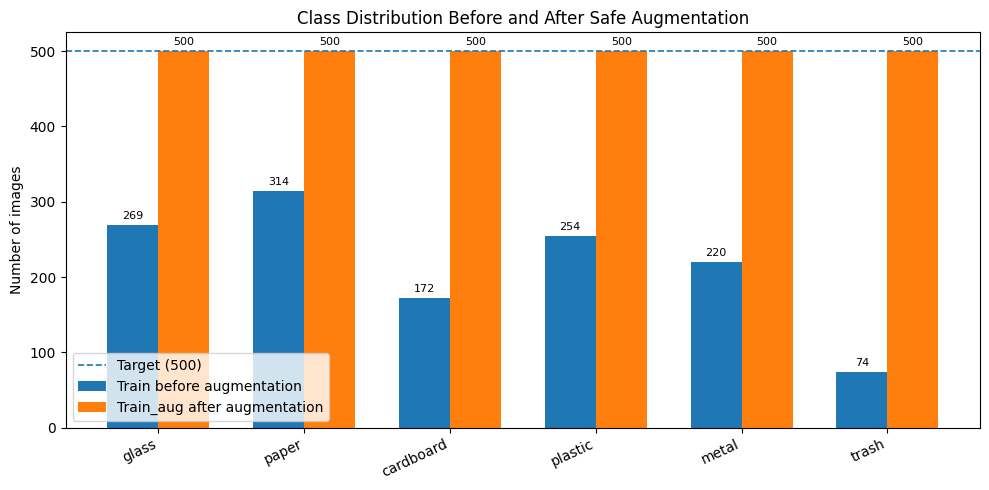

Chart saved → ..\data_split\reports\class_distribution_before_after.png


In [14]:
# CELL 14 — Bar chart: Train before vs train_aug

before_vals = [train_counts[c] for c in CLASSES]
after_vals  = [aug_counts[c] for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, before_vals, width, label="Train before augmentation")
bars2 = ax.bar(x + width / 2, after_vals,  width, label="Train_aug after augmentation")

ax.axhline(target_per_class, linestyle="--", linewidth=1.2, label=f"Target ({target_per_class})")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=25, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Class Distribution Before and After Safe Augmentation")
ax.legend()
ax.bar_label(bars1, padding=3, fontsize=8)
ax.bar_label(bars2, padding=3, fontsize=8)
plt.tight_layout()

chart_path = REPORTS_PATH / "class_distribution_before_after.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Chart saved → {chart_path}")


In [15]:
# CELL 15 — Final paths for next notebooks

print("Use these paths in feature extraction / model training:")
print(f"INPUT_TRAIN_PATH = '{AUG_TRAIN_PATH.as_posix()}'")
print(f"VAL_PATH         = '{VAL_PATH.as_posix()}'")
print(f"TEST_PATH        = '{TEST_PATH.as_posix()}'")

print("\nEquivalent original style:")
print("INPUT_PATH  = '../data_split/train_aug'")
print("VAL_PATH    = '../data_split/val'")
print("TEST_PATH   = '../data_split/test'")

print("\n Hybrid same-path augmentation pipeline finished")


Use these paths in feature extraction / model training:
INPUT_TRAIN_PATH = '../data_split/train_aug'
VAL_PATH         = '../data_split/val'
TEST_PATH        = '../data_split/test'

Equivalent original style:
INPUT_PATH  = '../data_split/train_aug'
VAL_PATH    = '../data_split/val'
TEST_PATH   = '../data_split/test'

 Hybrid same-path augmentation pipeline finished
